In [1]:
# !pip install -q tensorflowjs opencv-python

import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)]
        )
        print("GPU memory limit set to 4GB")
    except RuntimeError as e:
        print(e)

GPU memory limit set to 4GB


In [4]:
# from google.colab import files, drive
# drive.mount('/content/drive')
DATASET_DIR = 'synthetic_dataset'

In [5]:
params_df = pd.read_csv(os.path.join(DATASET_DIR, 'params.csv'))
params_df['low_image'] = params_df['low_image'].str.replace('\\', '/', regex=False)
params_df['original_image'] = params_df['original_image'].str.replace('\\', '/', regex=False)

print(f"Total pairs: {len(params_df)}")
print(f"Unique originals: {params_df['original_image'].nunique()}")

Total pairs: 50000
Unique originals: 50000


In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(splitter.split(params_df, groups=params_df['original_image']))

train_df = params_df.iloc[train_idx].reset_index(drop=True)
val_df = params_df.iloc[val_idx].reset_index(drop=True)

print(f"Training pairs: {len(train_df)}")
print(f"Validation pairs: {len(val_df)}")

Training pairs: 45000
Validation pairs: 5000


In [ ]:
IMG_SIZE = (256, 256)

def load_image(path, resize_to):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, resize_to, interpolation=cv2.INTER_LANCZOS4)
    img = img.astype(np.float32) / 255.
    return img

def apply_correction_tf(inputs, params):
    b = tf.reshape(params[:, 0:1], [-1, 1, 1, 1])
    c = tf.reshape(params[:, 1:2], [-1, 1, 1, 1])
    s = tf.reshape(params[:, 2:3], [-1, 1, 1, 1])

    x = inputs + b
    x = (x - 0.5) * c + 0.5
    r, g, b_ch = x[..., 0:1], x[..., 1:2], x[..., 2:3]
    luma = 0.299 * r + 0.587 * g + 0.114 * b_ch
    x = luma + (x - luma) * s
    return tf.clip_by_value(x, 0.0, 1.0)

def data_generator(df, batch_size=64, shuffle=True):
    while True:
        if shuffle:
            df = df.sample(frac=1).reset_index(drop=True)
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start:start+batch_size]
            X_low, X_orig = [], []
            for _, row in batch.iterrows():
                low_path  = os.path.join(DATASET_DIR, row['low_image'])
                orig_path = os.path.join(DATASET_DIR, row['original_image'])
                
                if not os.path.exists(low_path):
                    print(f"WARNING: missing {low_path}, skipping")
                    continue
                if not os.path.exists(orig_path):
                    print(f"WARNING: missing {orig_path}, skipping")
                    continue

                X_low.append(load_image(low_path, IMG_SIZE))
                X_orig.append(load_image(orig_path, IMG_SIZE))
            
            if len(X_low) == 0:
                continue
                
            yield (
                np.array(X_low, dtype=np.float32),
                np.array(X_orig, dtype=np.float32)
            )

batch_size = 64
steps_per_epoch = len(train_df) // batch_size
validation_steps = len(val_df) // batch_size

train_gen = data_generator(train_df, batch_size, shuffle=True)
val_gen = data_generator(val_df, batch_size, shuffle=False)

In [8]:
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = ssim_loss(y_true, y_pred)
    grad_true = tf.image.sobel_edges(y_true)
    grad_pred = tf.image.sobel_edges(y_pred)
    grad_loss = tf.reduce_mean(tf.abs(grad_true - grad_pred))
    return mse * 0.5 + ssim * 0.3 + grad_loss * 0.2

In [ ]:
def create_model(input_shape=(256, 256, 3)):
    inputs = keras.Input(shape=input_shape, name='low')

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)

    b = layers.Dense(1, activation='tanh')(x) * 0.4
    c = layers.Dense(1, activation='sigmoid')(x) * 1.8 + 0.2
    s = layers.Dense(1, activation='sigmoid')(x) * 1.8 + 0.2

    params = layers.Concatenate(name='params')([b, c, s])

    corrected = layers.Lambda(
        lambda x: apply_correction_tf(x[0], x[1]), name='corrected'
    )([inputs, params])

    train_model = keras.Model(inputs, corrected, name='enhancer_train')
    infer_model = keras.Model(inputs, params, name='enhancer_infer')
    return train_model, infer_model

train_model, infer_model = create_model()
train_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=combined_loss,
    metrics=['mae', ssim_loss]
)
train_model.summary()

Model: "enhancer_train"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 low (InputLayer)               [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 32  896         ['low[0][0]']                    
                                )                                                                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 128, 128, 32  0           ['conv2d[0][0]']                 
                                )                                                    

In [10]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
]

history = train_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=100,
    validation_data=val_gen,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
703/703 [==============================] - 312s 434ms/step - loss: 0.0957 - mae: 0.1267 - ssim_loss: 0.2471 - val_loss: 0.0923 - val_mae: 0.1218 - val_ssim_loss: 0.2373 - lr: 0.0010
Epoch 2/100
703/703 [==============================] - 291s 413ms/step - loss: 0.0913 - mae: 0.1194 - ssim_loss: 0.2365 - val_loss: 0.0899 - val_mae: 0.1174 - val_ssim_loss: 0.2332 - lr: 0.0010
Epoch 3/100
703/703 [==============================] - 286s 408ms/step - loss: 0.0886 - mae: 0.1148 - ssim_loss: 0.2305 - val_loss: 0.0867 - val_mae: 0.1128 - val_ssim_loss: 0.2225 - lr: 0.0010
Epoch 4/100
703/703 [==============================] - 284s 404ms/step - loss: 0.0858 - mae: 0.1109 - ssim_loss: 0.2235 - val_loss: 0.0858 - val_mae: 0.1124 - val_ssim_loss: 0.2215 - lr: 0.0010
Epoch 5/100
703/703 [==============================] - 283s 403ms/step - loss: 0.0837 - mae: 0.1080 - ssim_loss: 0.2181 - val_loss: 0.0829 - val_mae: 0.1072 - val_ssim_loss: 0.2157 - lr: 0.0010
Epoch 6/100
703/703 [=========

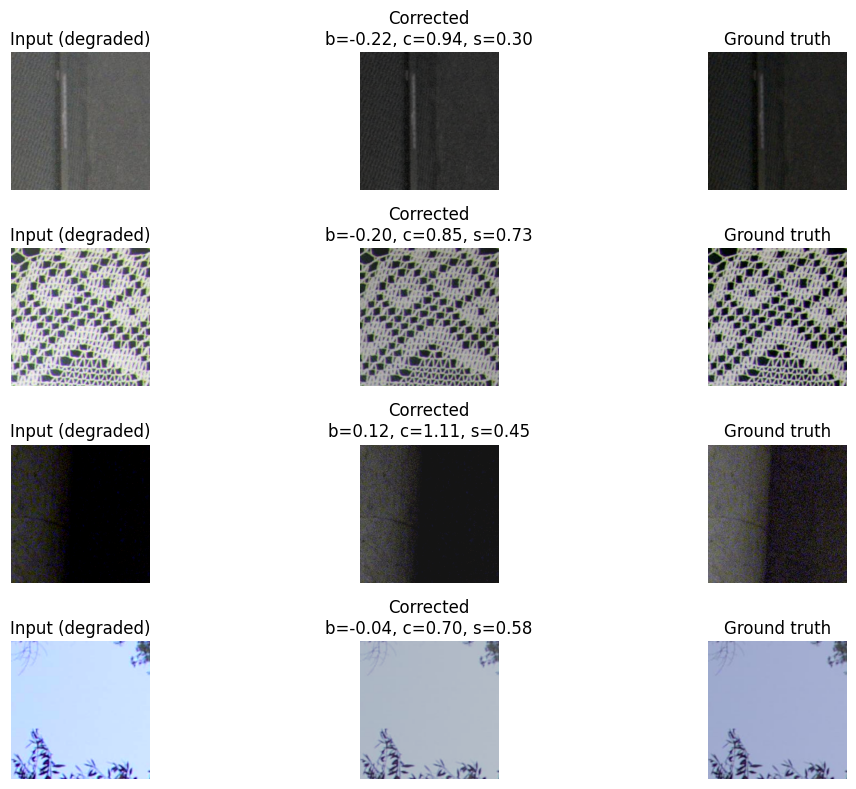

In [ ]:
def denormalize(img):
    return (img * 255).astype(np.uint8)

sample_df = val_df.sample(4).reset_index(drop=True)

plt.figure(figsize=(12, 8))
for i, row in sample_df.iterrows():
    low_path  = os.path.join(DATASET_DIR, row['low_image'])
    orig_path = os.path.join(DATASET_DIR, row['original_image'])

    low_img  = load_image(low_path, IMG_SIZE)
    orig_img = load_image(orig_path, IMG_SIZE)

    corrected_img = train_model.predict(np.expand_dims(low_img, axis=0), verbose=0)[0]
    pred_params = infer_model.predict(np.expand_dims(low_img, axis=0), verbose=0)[0]

    plt.subplot(4, 3, i*3+1)
    plt.imshow(denormalize(low_img))
    plt.title('Input (degraded)')
    plt.axis('off')

    plt.subplot(4, 3, i*3+2)
    plt.imshow(denormalize(corrected_img))
    plt.title(f'Corrected\nb={pred_params[0]:.2f}, c={pred_params[1]:.2f}, s={pred_params[2]:.2f}')
    plt.axis('off')

    plt.subplot(4, 3, i*3+3)
    plt.imshow(denormalize(orig_img))
    plt.title('Ground truth')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
SAVE_DIR = 'IEM_FIVEC'
os.makedirs(SAVE_DIR, exist_ok=True)

tf.saved_model.save(infer_model, os.path.join(SAVE_DIR, 'saved_model'))

infer_model.save(os.path.join(SAVE_DIR, 'best_model.h5'))

!mkdir -p tfjs_model
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    --signature_name=serving_default \
    --saved_model_tags=serve \
    {SAVE_DIR}/saved_model \
    tfjs_model

print(f"Готово. Проверьте размер:")
!du -sh tfjs_model/*

INFO:tensorflow:Assets written to: IEM_FIVEC\saved_model\assets


INFO:tensorflow:Assets written to: IEM_FIVEC\saved_model\assets


Готово. Проверьте размер:


Traceback (most recent call last):
  File "C:\ProgramData\miniconda3\envs\tf_gpu\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\miniconda3\envs\tf_gpu\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\miniconda3\envs\tf_gpu\Scripts\tensorflowjs_converter.exe\__main__.py", line 2, in <module>
  File "C:\ProgramData\miniconda3\envs\tf_gpu\lib\site-packages\tensorflowjs\__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "C:\ProgramData\miniconda3\envs\tf_gpu\lib\site-packages\tensorflowjs\converters\__init__.py", line 21, in <module>
    from tensorflowjs.converters.converter import convert
  File "C:\ProgramData\miniconda3\envs\tf_gpu\lib\site-packages\tensorflowjs\converters\converter.py", line 31, in <module>
    import tf_keras
  File "C:\ProgramData\miniconda3\envs\tf_gpu\lib\site-packages\tf_keras\__init__.py", line 3, in <module>
    from tf_ke

In [16]:
import pickle
with open("history.pkl", "wb") as f:
    pickle.dump(history.history, f)